In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

df = pd.read_csv("yamato_consolidated.csv")
df["ds"] = pd.to_datetime(df["ds"])
print(f"Loaded {len(df)} rows")
print(df[["ds","y"]].head())

Loaded 24 rows
          ds          y
0 2022-04-01  -78125208
1 2022-05-01  -76031333
2 2022-06-01  -36512945
3 2022-07-01 -207006205
4 2022-08-01 -274765519


In [2]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95
)
model.fit(df[["ds","y"]])
print("Model trained")

05:39:21 - cmdstanpy - INFO - Chain [1] start processing
05:39:48 - cmdstanpy - INFO - Chain [1] done processing


Model trained


In [3]:
future = model.make_future_dataframe(periods=6, freq="MS")
forecast = model.predict(future)
print(forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(10))

           ds          yhat    yhat_lower    yhat_upper
20 2023-12-01 -1.255243e+08 -1.255243e+08 -1.255243e+08
21 2024-01-01  1.322761e+08  1.322761e+08  1.322761e+08
22 2024-02-01  1.278744e+08  1.278744e+08  1.278744e+08
23 2024-03-01  3.978928e+07  3.978928e+07  3.978928e+07
24 2024-04-01  5.266786e+06  5.012414e+06  5.485852e+06
25 2024-05-01  7.475465e+07  7.394884e+07  7.543281e+07
26 2024-06-01  2.175629e+08  2.160827e+08  2.188919e+08
27 2024-07-01 -1.530743e+08 -1.553176e+08 -1.508844e+08
28 2024-08-01 -3.953102e+08 -3.984865e+08 -3.921876e+08
29 2024-09-01  1.395168e+08  1.352895e+08  1.435275e+08


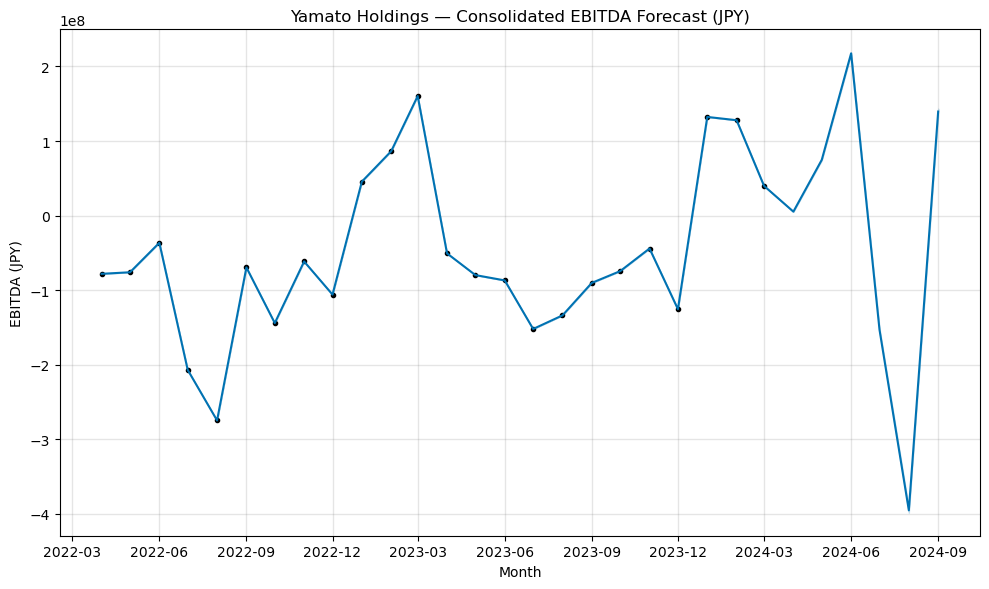

Chart saved as forecast.png


In [4]:
fig = model.plot(forecast)
plt.title("Yamato Holdings — Consolidated EBITDA Forecast (JPY)")
plt.xlabel("Month")
plt.ylabel("EBITDA (JPY)")
plt.tight_layout()
plt.savefig("forecast.png", dpi=150)
plt.show()
print("Chart saved as forecast.png")

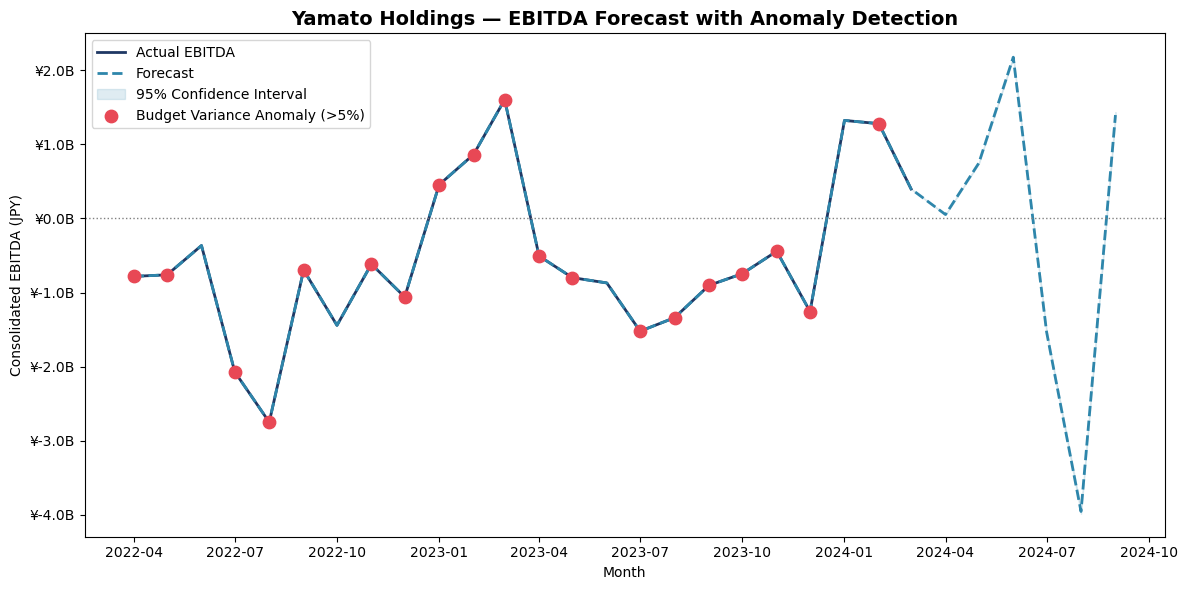

Anomalies flagged: 19


In [5]:
# Merge forecast with actuals
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].copy()
results = results.merge(df[["ds","y","ebitda_vs_budget_pct"]], on="ds", how="left")

# Flag anomalies: actual deviates >5% from budget revenue
THRESHOLD = 5.0
results["is_anomaly"] = (
    results["ebitda_vs_budget_pct"].notna() &
    (abs(results["ebitda_vs_budget_pct"]) > THRESHOLD)
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(results["ds"], results["y"], label="Actual EBITDA", color="#1F3864", linewidth=2)
ax.plot(results["ds"], results["yhat"], label="Forecast", color="#2E86AB", linewidth=2, linestyle="--")
ax.fill_between(results["ds"], results["yhat_lower"], results["yhat_upper"],
                alpha=0.15, color="#2E86AB", label="95% Confidence Interval")

# Highlight anomalies
anomalies = results[results["is_anomaly"] == True]
ax.scatter(anomalies["ds"], anomalies["y"],
           color="#E84855", zorder=5, s=80, label="Budget Variance Anomaly (>5%)")

ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.set_title("Yamato Holdings — EBITDA Forecast with Anomaly Detection", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Consolidated EBITDA (JPY)")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"¥{x/1e8:.1f}B"))
plt.tight_layout()
plt.savefig("forecast_with_anomalies.png", dpi=150)
plt.show()
print(f"Anomalies flagged: {results['is_anomaly'].sum()}")

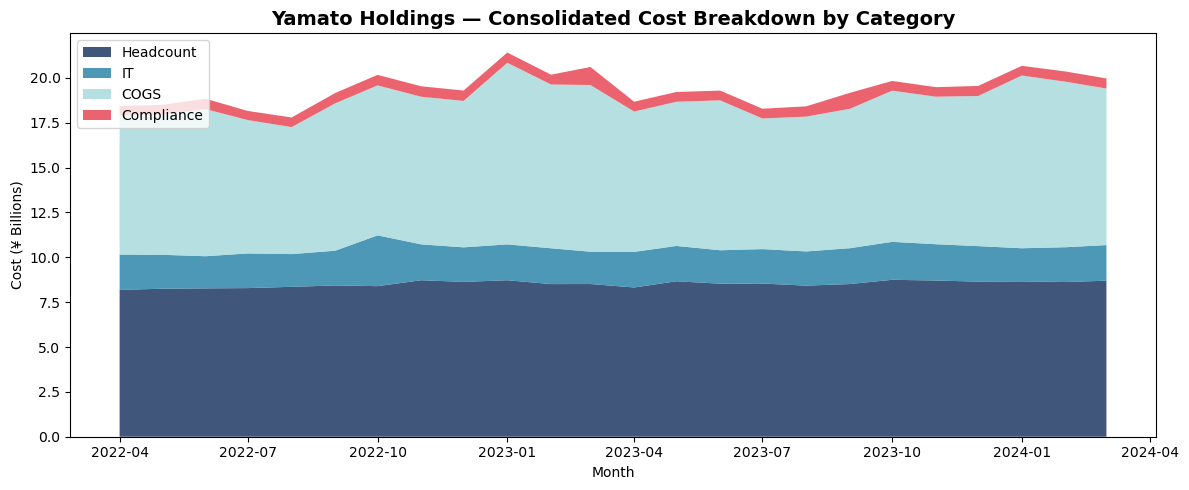

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.stackplot(df["ds"],
    df["exp_headcount_jpy"] / 1e8,
    df["exp_it_jpy"] / 1e8,
    df["exp_cogs_jpy"] / 1e8,
    df["exp_compliance_jpy"] / 1e8,
    labels=["Headcount", "IT", "COGS", "Compliance"],
    colors=["#1F3864", "#2E86AB", "#A8DADC", "#E84855"],
    alpha=0.85)

ax.set_title("Yamato Holdings — Consolidated Cost Breakdown by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Cost (¥ Billions)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("cost_breakdown.png", dpi=150)
plt.show()